In [23]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import pandas as pd
import os

In [24]:
df = pd.read_csv("../data/processed/csgo_cleaned_3.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 875110 entries, 0 to 875109
Data columns (total 32 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                875110 non-null  int64  
 1   map                       875110 non-null  str    
 2   round                     875110 non-null  int64  
 3   att_team                  875110 non-null  str    
 4   vic_team                  875110 non-null  str    
 5   att_side                  875110 non-null  str    
 6   vic_side                  875110 non-null  str    
 7   is_bomb_planted           875110 non-null  bool   
 8   bomb_site                 135616 non-null  str    
 9   wp                        875110 non-null  str    
 10  wp_type                   875110 non-null  str    
 11  winner_team               875110 non-null  str    
 12  winner_side               875110 non-null  str    
 13  att_pos_x                 875110 non-null  float64
 14 

In [25]:
df2 = df[df["map"] == "de_mirage"]
df3 = df2[["total_dmg", "is_headshot", "wp", "inbetween_distance", "att_distance_to_bombsite", "vic_distance_to_bombsite", "att_tier", "vic_tier"]]
df3.info()

<class 'pandas.DataFrame'>
Index: 256034 entries, 776 to 871843
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   total_dmg                 256034 non-null  int64  
 1   is_headshot               256034 non-null  bool   
 2   wp                        256034 non-null  str    
 3   inbetween_distance        256034 non-null  float64
 4   att_distance_to_bombsite  256034 non-null  float64
 5   vic_distance_to_bombsite  256034 non-null  float64
 6   att_tier                  256034 non-null  str    
 7   vic_tier                  256034 non-null  str    
dtypes: bool(1), float64(3), int64(1), str(3)
memory usage: 15.9 MB


In [26]:
from pandas.api.types import CategoricalDtype

custom_order = CategoricalDtype(categories=['Silver', 'Gold Nova', 'Master Guardian', 'Top Four'], ordered=True)
df3["att_tier"] = df3["att_tier"].astype(custom_order)
df3["vic_tier"] = df3["vic_tier"].astype(custom_order)

X1 = df3.drop(columns = ["att_tier", "vic_tier", "vic_distance_to_bombsite"])
X2 = df3.drop(columns = ["att_tier", "vic_tier", "att_distance_to_bombsite"])
y1 = df3["att_tier"].cat.codes
y2 = df3["vic_tier"].cat.codes

X1["is_headshot"] = X1["is_headshot"].astype(int)
X1["wp"] = X1["wp"].astype("category")

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X1,
    y1,
    test_size=0.2,
    random_state=42,
    stratify=y1
)

In [28]:
import numpy as np
import warnings
from scipy.stats import uniform, randint, loguniform
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore", category=UserWarning)

# 1. Compute sample weights to balance rare vs. common ranks
sample_weights = compute_sample_weight("balanced", y_train)

# 2. Base model setup
base_model = XGBClassifier(
    objective="multi:softprob",
    num_class=4,
    eval_metric="mlogloss",
    device="cuda",
    enable_categorical=True,
    tree_method="hist",
    random_state=42
)

# 3. Search space
param_distributions = {

    "n_estimators":[100,250,500,750],

    "learning_rate":loguniform(0.01,0.2),

    "max_depth":randint(3,10),

    "subsample":uniform(0.6,0.4),

    "colsample_bytree":uniform(0.6,0.4),

    "min_child_weight":randint(1,10),

    "gamma":loguniform(1e-3,5),

    "reg_alpha":loguniform(1e-3,10),

    "reg_lambda":loguniform(1e-3,10)

}

# 4. RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=50,
    scoring="f1_macro",   # 'f1_macro' gives equal importance to all rank tiers
    cv=5,
    random_state=42,
    n_jobs=1,
    verbose=3
)

# 5. Fit passing sample_weight directly to XGBoost
random_search.fit(X_train, y_train, sample_weight=sample_weights)

# 6. Evaluate
best_model = random_search.best_estimator_
predictions = best_model.predict(X_test)

print("\n--- Balanced Classification Report ---")
print(classification_report(y_test, predictions))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END colsample_bytree=0.749816047538945, gamma=3.2859708169642414, learning_rate=0.08960785365368121, max_depth=7, min_child_weight=5, n_estimators=500, reg_alpha=0.06071989493441298, reg_lambda=0.002511306167739001, subsample=0.7836995567863468;, score=0.378 total time=  10.5s
[CV 2/5] END colsample_bytree=0.749816047538945, gamma=3.2859708169642414, learning_rate=0.08960785365368121, max_depth=7, min_child_weight=5, n_estimators=500, reg_alpha=0.06071989493441298, reg_lambda=0.002511306167739001, subsample=0.7836995567863468;, score=0.373 total time=  10.4s
[CV 3/5] END colsample_bytree=0.749816047538945, gamma=3.2859708169642414, learning_rate=0.08960785365368121, max_depth=7, min_child_weight=5, n_estimators=500, reg_alpha=0.06071989493441298, reg_lambda=0.002511306167739001, subsample=0.7836995567863468;, score=0.377 total time=   9.8s
[CV 4/5] END colsample_bytree=0.749816047538945, gamma=3.2859708169642414, le

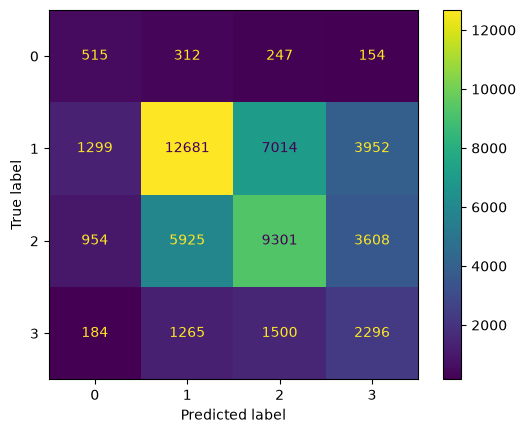

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

disp.figure_.savefig('../images/06_confusion_matrix.png')